In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Carregando as tabelas que vamos usar
orders = pd.read_csv('../data/olist_orders_dataset.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
translation = pd.read_csv('../data/product_category_name_translation.csv')

In [5]:
# Quantas linhas e colunas tem cada tabela?
print("orders:", orders.shape)
print("items:", items.shape)
print("products:", products.shape)
print("reviews:", reviews.shape)
print("translation:", translation.shape)

orders: (99441, 8)
items: (112650, 7)
products: (32951, 9)
reviews: (99224, 7)
translation: (71, 2)


In [6]:
# Primeiras linhas da tabela central
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [8]:
items.colums.tolist()

AttributeError: 'DataFrame' object has no attribute 'colums'

In [9]:
items.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value']

In [10]:
# Unindo items com products pra trazer a categoria
df = items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')

# Traduzindo a categoria pro inglês
df = df.merge(translation, on='product_category_name', how='left')

df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools


In [11]:
# Unindo com as avaliações pelo order_id
df = df.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# Verificando o resultado
print(df.shape)
df.head()

(113314, 10)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools,5.0


In [12]:
# Verificando valores nulos
df[['price', 'product_category_name_english', 'review_score']].isnull().sum()

price                               0
product_category_name_english    1636
review_score                      942
dtype: int64

In [13]:
# Usando a categoria em português onde não tem tradução
df['categoria'] = df['product_category_name_english'].fillna(df['product_category_name'])

df['categoria'].isnull().sum()

np.int64(1612)

In [14]:
df['categoria'] = df['categoria'].fillna('sem_categoria')

df['categoria'].isnull().sum()

np.int64(0)

In [15]:
# Receita total por categoria
receita_por_categoria = (
    df.groupby('categoria')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

receita_por_categoria.columns = ['categoria', 'receita_total']
receita_por_categoria

,categoria,receita_total
0,health_beauty,1263138.54
1,watches_gifts,1206075.33
2,bed_bath_table,1050936.61
3,sports_leisure,993656.51
4,computers_accessories,919640.54
5,furniture_decor,736282.47
6,cool_stuff,637258.51
7,housewares,634542.60
8,auto,594363.10
9,garden_tools,486432.45


/tmp/ipykernel_10264/2794845801.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=receita_por_categoria, x='receita_total', y='categoria', palette='viridis')


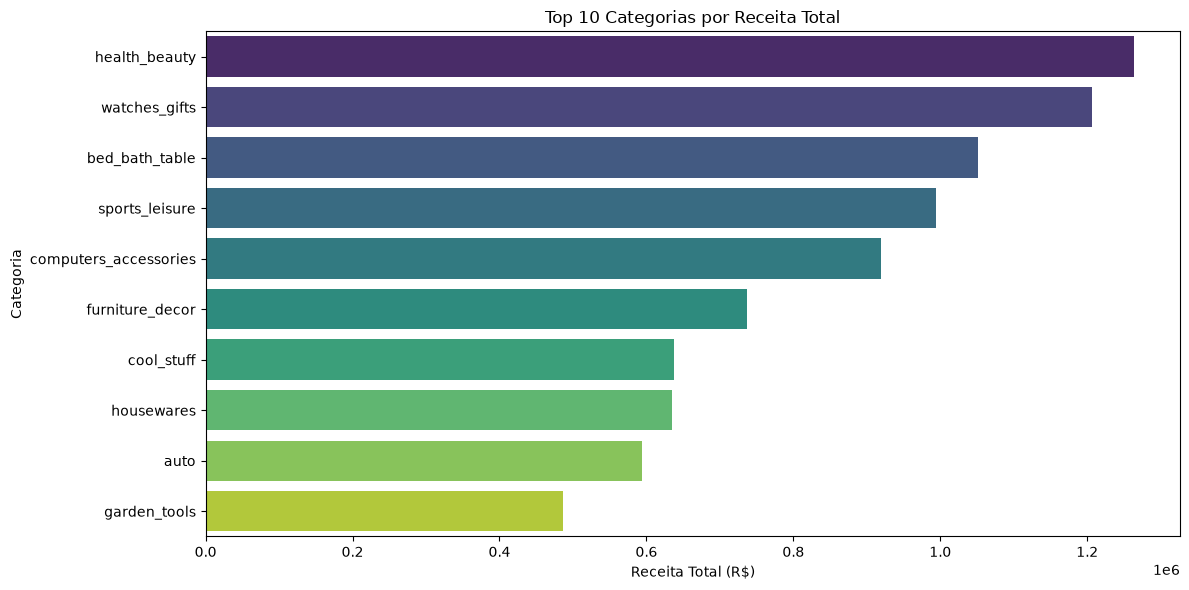

In [16]:
# Gráfico de receita por categoria
plt.figure(figsize=(12, 6))
sns.barplot(data=receita_por_categoria, x='receita_total', y='categoria', palette='viridis')
plt.title('Top 10 Categorias por Receita Total')
plt.xlabel('Receita Total (R$)')
plt.ylabel('Categoria')
plt.tight_layout()
plt.show()

In [17]:
# Ticket médio por categoria (top 10 de receita)
ticket_medio = (
    df[df['categoria'].isin(receita_por_categoria['categoria'])]
    .groupby('categoria')['price']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

ticket_medio.columns = ['categoria', 'ticket_medio']
ticket_medio

,categoria,ticket_medio
0,watches_gifts,200.979058
1,cool_stuff,167.435236
2,auto,139.652984
3,health_beauty,129.859005
4,computers_accessories,116.498675
5,sports_leisure,114.213392
6,garden_tools,111.541493
7,bed_bath_table,93.250808
8,housewares,90.791615
9,furniture_decor,87.496431


In [18]:
# Avaliação média por categoria (só top 10 de receita, removendo nulos de review)
avaliacao = (
    df[df['categoria'].isin(receita_por_categoria['categoria'])]
    .dropna(subset=['review_score'])
    .groupby('categoria')['review_score']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

avaliacao.columns = ['categoria', 'nota_media']
avaliacao

,categoria,nota_media
0,cool_stuff,4.146341
1,health_beauty,4.142768
2,sports_leisure,4.107986
3,auto,4.065512
4,housewares,4.055019
5,garden_tools,4.042735
6,watches_gifts,4.019160
7,computers_accessories,3.930819
8,furniture_decor,3.903493
9,bed_bath_table,3.895663


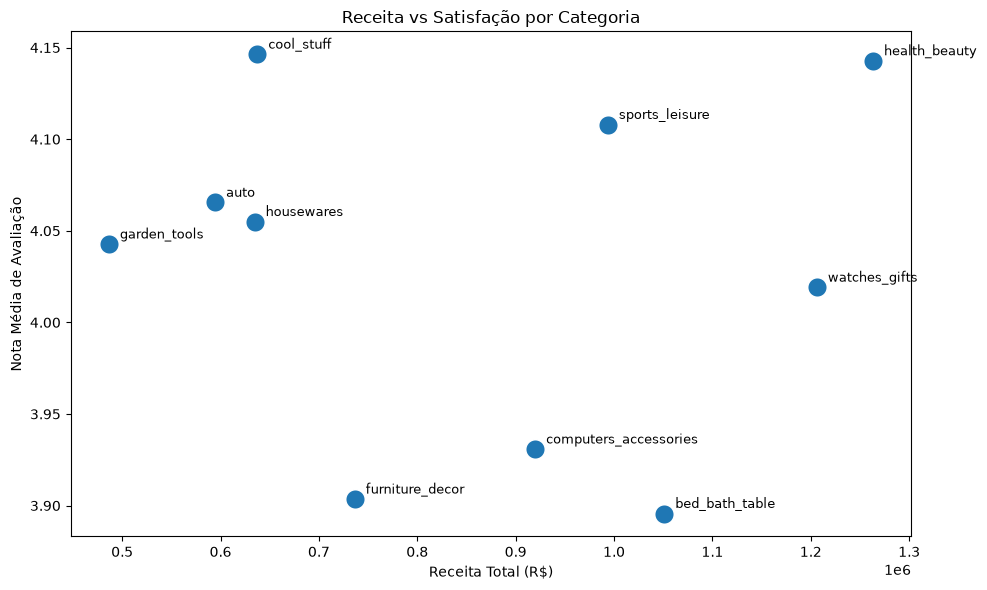

In [19]:
# Cruzando receita com avaliação
final = receita_por_categoria.merge(avaliacao, on='categoria')

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=final,
    x='receita_total',
    y='nota_media',
    s=200
)

for _, row in final.iterrows():
    plt.annotate(row['categoria'], (row['receita_total'], row['nota_media']),
                 textcoords="offset points", xytext=(8, 4), fontsize=9)

plt.title('Receita vs Satisfação por Categoria')
plt.xlabel('Receita Total (R$)')
plt.ylabel('Nota Média de Avaliação')
plt.tight_layout()
plt.show()

## Principais Insights

- **health_beauty** e a categoria ideal: maior receita total e segunda melhor avaliacao (4.14)
- **watches_gifts** tem o maior ticket medio (R$200) mas receita menor - vende pouco e caro
- **bed_bath_table** vende muito em volume mas tem a pior avaliacao (3.89) - possivel problema de qualidade ou entrega
- **computers_accessories** e **furniture_decor** ficam abaixo de 4.0 na avaliacao - categorias que merecem atencao

In [20]:
# Convertendo a data de compra para o formato correto
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Extraindo o mês/ano
orders['mes_ano'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Contando pedidos por mês
pedidos_por_mes = (
    orders[orders['order_status'] == 'delivered']
    .groupby('mes_ano')
    .size()
    .reset_index()
)

pedidos_por_mes.columns = ['mes_ano', 'total_pedidos']
pedidos_por_mes['mes_ano'] = pedidos_por_mes['mes_ano'].astype(str)

pedidos_por_mes.tail(10)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,mes_ano,total_pedidos
13,2017-11,7289
14,2017-12,5513
15,2018-01,7069
16,2018-02,6555
17,2018-03,7003
18,2018-04,6798
19,2018-05,6749
20,2018-06,6099
21,2018-07,6159
22,2018-08,6351


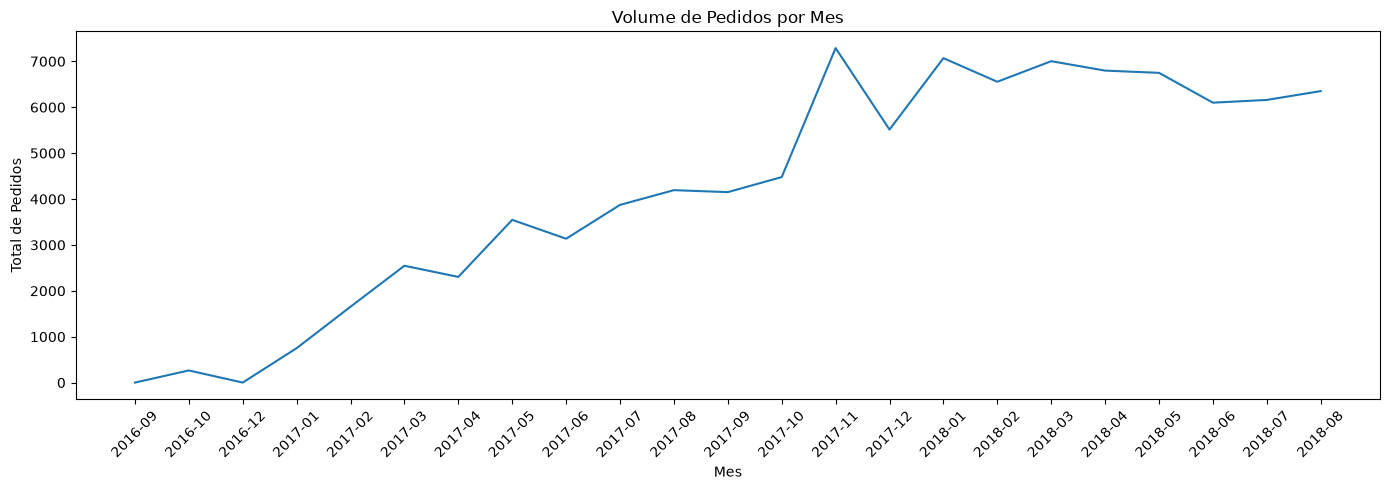

In [21]:
# Grafico de pedidos ao longo do tempo
plt.figure(figsize=(14, 5))
sns.lineplot(data=pedidos_por_mes, x='mes_ano', y='total_pedidos')
plt.title('Volume de Pedidos por Mes')
plt.xlabel('Mes')
plt.ylabel('Total de Pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Sazonalidade

- Crescimento acelerado entre 2016 e 2017
- Pico em novembro de 2017 - provavel Black Friday
- Estabilizacao entre 6.000 e 7.000 pedidos por mes em 2018